In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('data/processed/train_processed.csv')
test = pd.read_csv('data/processed/test_processed.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
#读取处理后的数据

Train shape: (891, 20)
Test shape: (418, 19)


In [9]:
#分离特征x和标签y
X = train.drop(columns=['PassengerId', 'Survived'])
y = train['Survived']

test_passenger_id = test['PassengerId']
X_test_final = test.drop(columns=['PassengerId'])

print(X.shape, y.shape, X_test_final.shape)
print(X.columns.tolist())

(891, 18) (891,) (418, 18)
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize', 'IsAlone', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Title_the Countess']


In [10]:
#划分训练集和验证集
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("训练集:", X_train.shape, "验证集:", X_val.shape)

训练集: (712, 18) 验证集: (179, 18)


In [ ]:
#Baseline模型
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_val)
print("Baseline的验证集准确率:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

In [ ]:
#决策树
dt.fit(X_train, y_train)

y_pred = dt.predict(X_val)
print("决策树的验证集准确率:", accuracy_score(y_val, y_pred))

In [20]:
#随机森林
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)
print("随机森林 验证集准确率:", accuracy_score(y_val, y_pred))

随机森林 验证集准确率: 0.8156424581005587


In [ ]:
#用交叉验证做更可靠的模型对比
models ={
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

In [ ]:
#可视化的对比结果
results_df = pd.DataFrame(results)

plt.figure(figsize=(8, 5))
sns.boxplot(data=results_df)
plt.ylabel('Accuracy')
plt.show()

               feature  importance
14            Title_Mr    0.279170
5                 Fare    0.119716
13          Title_Miss    0.094071
0               Pclass    0.091516
15           Title_Mrs    0.085519
2                  Age    0.083983
6             HasCabin    0.062746
7           FamilySize    0.057753
3                SibSp    0.036700
4                Parch    0.016809
16          Title_Rare    0.016691
9           Embarked_C    0.012867
8              IsAlone    0.012354
11          Embarked_S    0.011538
12        Title_Master    0.011108
10          Embarked_Q    0.007145
17  Title_the Countess    0.000315
1                  Sex    0.000000


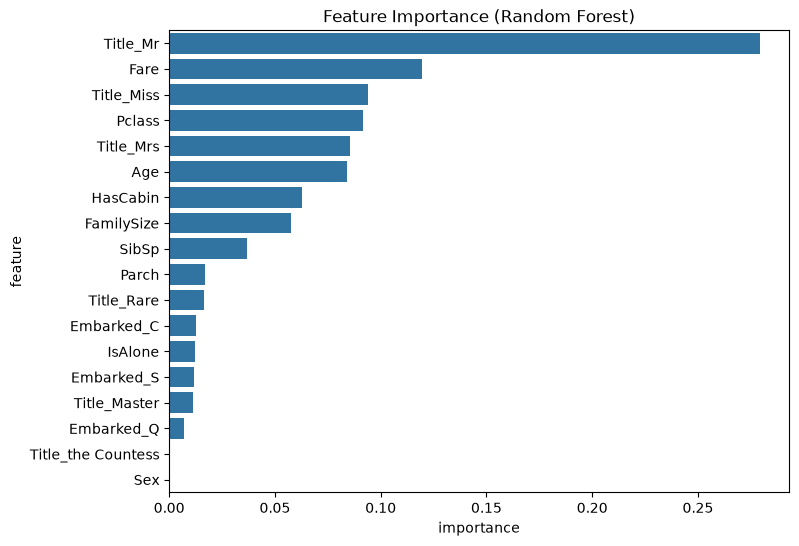

In [25]:
#查看随机森林的重要特性
rf_full = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf_full.fit(X, y)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_full.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Feature Importance (Random Forest)')
plt.show()

In [26]:
#选定最终模型，并对test进行预测
final_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
final_model.fit(X, y)

test_predictions = final_model.predict(X_test_final)
test_predictions = test_predictions.astype(int)

print(test_predictions[:10])

[0 0 0 0 1 0 1 0 1 0]


In [27]:
#组装成kaggle格式
submission = pd.DataFrame({
    'PassengerId': test_passenger_id,
    'Survived': test_predictions
})

print(submission.head())
print(submission.shape)

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
(418, 2)


In [28]:
#保存csv文件
import os
os.makedirs('/submissions', exist_ok=True)

submission.to_csv('/submissions/submission_v1.csv', index=False)
print("已保存 submission_v1.csv")

已保存 submission_v1.csv


In [29]:
#格式检查
#行数必须是418
assert submission.shape[0] == 418

#无缺失值
assert submission.isnull().sum().sum() == 0

#Survived的值只能是0或1
assert set(submission['Survived'].unique()) <= {0, 1}